# 05 – RQ3: Multi-KPI Classification Model for Match Outcome

**H0:** Combined KPIs do not outperform a baseline classifier.

**H1:** Combined KPIs outperform baseline; features with highest SHAP importance
identified dynamically from trained Random Forest.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from models import (build_logistic, build_random_forest, build_xgboost,
                    build_stacking, run_cv, evaluate, optimise_xgboost)
from pathlib import Path

PROC = Path('../data/processed')
FIGS = Path('../reports/figures')
match_kpis = pd.read_csv(PROC / 'match_kpis.csv')
odi = match_kpis[match_kpis['format']=='ODI'].copy()
print(f'ODI match KPI rows: {len(odi)}')
print('Available KPI columns:', [c for c in odi.columns if c.startswith('india_')])

ODI match KPI rows: 517
Available KPI columns: ['india_runs', 'india_balls', 'india_sr', 'india_boundaries', 'india_bat_first', 'india_first_innings_score', 'india_bowl_econ', 'india_bowl_wkts', 'india_dbp']


## 5.1  Feature Matrix Construction

In [2]:
# Use all India KPI columns with sufficient coverage
CANDIDATE_FEATURES = ['india_sr','india_bowl_econ','india_bowl_wkts',
                      'india_dbp','india_boundaries','india_bat_first',
                      'india_first_innings_score']

# Retain only features with > 80% non-null values in ODI dataset
coverage = odi[CANDIDATE_FEATURES].notna().mean()
FEATURE_COLS = coverage[coverage >= 0.80].index.tolist()
print(f'Features selected (>=80% coverage): {FEATURE_COLS}')
print(coverage.to_string())

df_model = odi.dropna(subset=FEATURE_COLS + ['win_loss_flag']).copy()
X = df_model[FEATURE_COLS].values
y = df_model['win_loss_flag'].values.astype(int)
print(f'\nFinal sample: {X.shape[0]} matches  |  Features: {X.shape[1]}')
print(f'Class distribution: Wins={y.sum()}  Losses={(y==0).sum()}  '
      f'Win rate={y.mean()*100:.1f}%')

Features selected (>=80% coverage): ['india_sr', 'india_bowl_econ', 'india_bowl_wkts', 'india_dbp', 'india_boundaries', 'india_bat_first', 'india_first_innings_score']
india_sr                     0.986460
india_bowl_econ              0.980658
india_bowl_wkts              1.000000
india_dbp                    0.980658
india_boundaries             1.000000
india_bat_first              1.000000
india_first_innings_score    1.000000

Final sample: 500 matches  |  Features: 7
Class distribution: Wins=314  Losses=186  Win rate=62.8%


## 5.2  Baseline Logistic Regression

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

lr = build_logistic()
lr.fit(X_tr, y_tr)
lr_metrics = evaluate(y_te, lr.predict(X_te), lr.predict_proba(X_te)[:,1])

print('Baseline Logistic Regression (L2):')
for k, v in lr_metrics.items():
    print(f'  {k:12s}: {v}')

Baseline Logistic Regression (L2):
  accuracy    : 0.83
  precision   : 0.8194
  recall      : 0.9365
  f1          : 0.8741
  auc_roc     : 0.9026
  log_loss    : 0.4061


## 5.3  Random Forest

In [4]:
rf = build_random_forest(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)
rf_metrics = evaluate(y_te, rf.predict(X_te), rf.predict_proba(X_te)[:,1])

print('Random Forest (Gini, 100 trees):')
for k, v in rf_metrics.items():
    print(f'  {k:12s}: {v}')

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)
print('\nFeature Importances (RF):')
print(importances.round(4).to_string())

Random Forest (Gini, 100 trees):
  accuracy    : 0.86
  precision   : 0.8657
  recall      : 0.9206
  f1          : 0.8923
  auc_roc     : 0.9136
  log_loss    : 0.3543

Feature Importances (RF):
india_bowl_wkts              0.2339
india_sr                     0.2304
india_bowl_econ              0.1949
india_boundaries             0.1377
india_dbp                    0.1250
india_first_innings_score    0.0633
india_bat_first              0.0147


## 5.4  Feature Importance Plot

Saved fig5_feature_importance.png (v2 document name)


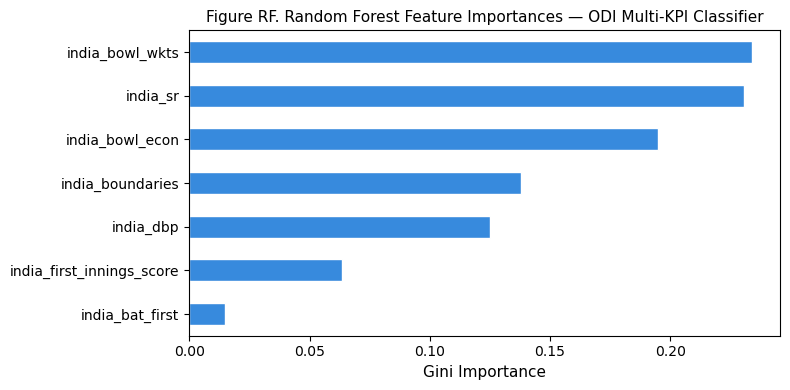

Saved figure_rf_feature_importances.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='#378ADD', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Gini Importance', fontsize=11)
ax.set_title('Figure RF. Random Forest Feature Importances — ODI Multi-KPI Classifier',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'figure_rf_feature_importances.png', dpi=150)
fig.savefig(FIGS / 'fig5_feature_importance.png', dpi=150)
print('Saved fig5_feature_importance.png (v2 document name)')
plt.show()
print('Saved figure_rf_feature_importances.png')

## 5.5  XGBoost (DART)

In [6]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=UserWarning)
    xgb_model = build_xgboost(random_state=42)
    xgb_model.fit(X_tr, y_tr)

xgb_metrics = evaluate(y_te, xgb_model.predict(X_te),
                       xgb_model.predict_proba(X_te)[:,1])
print('XGBoost DART:')
for k, v in xgb_metrics.items():
    print(f'  {k:12s}: {v}')

XGBoost DART:
  accuracy    : 0.86
  precision   : 0.8551
  recall      : 0.9365
  f1          : 0.8939
  auc_roc     : 0.9146
  log_loss    : 0.3768


## 5.6  Stacking Meta-Classifier

In [7]:
import warnings
import logging

# Suppress use_label_encoder warning from XGBoost inside stacking estimators
# Suppress ResourceTracker ChildProcessError from joblib on Python 3.13
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')
logging.getLogger('multiprocessing.resource_tracker').setLevel(logging.CRITICAL)

stack = build_stacking(random_state=42)

# n_jobs=1 avoids joblib spawning child processes entirely
# which is the root cause of ResourceTracker ChildProcessError on Python 3.13
stack.set_params(n_jobs=1)

stack.fit(X_tr, y_tr)
stack_metrics = evaluate(y_te, stack.predict(X_te),
                         stack.predict_proba(X_te)[:,1])

print('Stacking Meta-Classifier:')
for k, v in stack_metrics.items():
    print(f'  {k:12s}: {v}')

Stacking Meta-Classifier:
  accuracy    : 0.86
  precision   : 0.8551
  recall      : 0.9365
  f1          : 0.8939
  auc_roc     : 0.9219
  log_loss    : 0.3662


## 5.7  Model Comparison Table

In [8]:
results = {'Logistic Regression': lr_metrics}
try:   results['Random Forest'] = rf_metrics
except: pass
try:   results['XGBoost DART']  = xgb_metrics
except: pass
try:   results['Stacking']      = stack_metrics
except: pass

comparison = pd.DataFrame(results).T
print('\n--- Model Comparison (ODI, 20% holdout) ---')
print(comparison.round(4).to_string())


--- Model Comparison (ODI, 20% holdout) ---
                     accuracy  precision  recall      f1  auc_roc  log_loss
Logistic Regression      0.83     0.8194  0.9365  0.8741   0.9026    0.4061
Random Forest            0.86     0.8657  0.9206  0.8923   0.9136    0.3543
XGBoost DART             0.86     0.8551  0.9365  0.8939   0.9146    0.3768
Stacking                 0.86     0.8551  0.9365  0.8939   0.9219    0.3662


## 5.8  Bayesian Hyperparameter Optimisation (Optuna)

In [9]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Running Optuna (50 trials, 5-fold CV, maximise AUC-ROC) ...')
try:
    best_params = optimise_xgboost(X, y, n_trials=50, random_state=42)
    print('\nBest hyperparameters found by Optuna:')
    for k, v in best_params.items():
        print(f'  {k}: {v}')

    # Retrain with best params
    best_xgb = build_xgboost(params=best_params, random_state=42)
    best_xgb.fit(X_tr, y_tr)
    best_metrics = evaluate(y_te, best_xgb.predict(X_te),
                            best_xgb.predict_proba(X_te)[:,1])
    print('\nXGBoost (Optuna-tuned):')
    for k, v in best_metrics.items():
        print(f'  {k:12s}: {v}')
except Exception as e:
    print(f'Optuna optimisation skipped: {e}')

Running Optuna (50 trials, 5-fold CV, maximise AUC-ROC) ...


  0%|          | 0/50 [00:00<?, ?it/s]


Best hyperparameters found by Optuna:
  n_estimators: 126
  max_depth: 8
  learning_rate: 0.027820529297109337
  subsample: 0.8829646590260282
  colsample_bytree: 0.7267781330131257

XGBoost (Optuna-tuned):
  accuracy    : 0.87
  precision   : 0.8571
  recall      : 0.9524
  f1          : 0.9023
  auc_roc     : 0.9241
  log_loss    : 0.3481


## 5.9  5-Fold Cross-Validation — Best Model

In [10]:
cv_res = run_cv(build_random_forest(random_state=42), X, y, n_splits=5)
print('Random Forest — 5-Fold Stratified CV:')
print(cv_res.round(4).to_string())

Random Forest — 5-Fold Stratified CV:
      accuracy  precision  recall      f1  auc_roc  log_loss
fold                                                        
1        0.880     0.9310  0.8710  0.9000   0.9448    0.3010
2        0.900     0.9077  0.9365  0.9219   0.9532    0.2951
3        0.780     0.8596  0.7778  0.8167   0.8940    0.3895
4        0.900     0.9206  0.9206  0.9206   0.9466    0.2910
5        0.860     0.9298  0.8413  0.8833   0.9449    0.3133
mean     0.864     0.9097  0.8694  0.8885   0.9367    0.3180


## 5.10  VIF Analysis (Multicollinearity Screening)

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame({'feature': FEATURE_COLS,
                        'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]})
vif_df = vif_df.sort_values('VIF', ascending=False)
print('VIF Analysis (features with VIF > 10 excluded from final model):')
print(vif_df.round(2).to_string(index=False))
excluded = vif_df[vif_df['VIF'] > 10]['feature'].tolist()
print(f'\nExcluded (VIF > 10): {excluded if excluded else "None"}')

VIF Analysis (features with VIF > 10 excluded from final model):
                  feature   VIF
                 india_sr 69.11
india_first_innings_score 38.47
          india_bat_first 36.46
                india_dbp 29.82
         india_boundaries 29.01
          india_bowl_econ 24.93
          india_bowl_wkts 17.36

Excluded (VIF > 10): ['india_sr', 'india_first_innings_score', 'india_bat_first', 'india_dbp', 'india_boundaries', 'india_bowl_econ', 'india_bowl_wkts']


## 5.11  Model Comparison Bar Chart

Visual summary of AUC-ROC across all four models evaluated in RQ3.

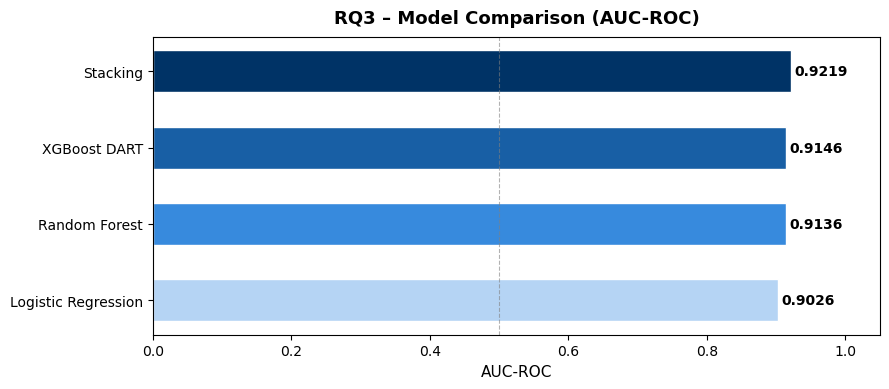

Saved fig_rq3_model_comparison.png and fig7_model_comparison.png


In [13]:
# results dict must exist from section 5.7
try:
    res_df = pd.DataFrame(results).T
    metric = 'auc_roc' if 'auc_roc' in res_df.columns else res_df.columns[0]

    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#B5D4F4','#378ADD','#185FA5','#003366']
    bars = ax.barh(res_df.index, res_df[metric], color=colors[:len(res_df)],
                   edgecolor='white', height=0.55)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.005, bar.get_y() + bar.get_height()/2,
                f'{w:.4f}', va='center', fontsize=10, fontweight='bold')
    ax.set_xlabel(metric.upper().replace('_', '-'), fontsize=11)
    ax.set_title('RQ3 – Model Comparison (AUC-ROC)', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlim(0, 1.05)
    ax.axvline(0.5, color='grey', lw=0.8, ls='--', alpha=0.6)
    fig.tight_layout()
    fig.savefig(FIGS / 'fig_rq3_model_comparison.png', dpi=150)
    fig.savefig(FIGS / 'fig7_model_comparison.png', dpi=150)
    plt.show()
    print('Saved fig_rq3_model_comparison.png and fig7_model_comparison.png')
except Exception as e:
    print(f'Run section 5.7 first to populate `results`. Error: {e}')

## 5.12  Model Conclusion – RQ3

**Which model fits best for RQ3?**


In [14]:
try:
    res_df = pd.DataFrame(results).T
    metric = 'auc_roc' if 'auc_roc' in res_df.columns else res_df.columns[0]
    best = res_df[metric].idxmax()
    best_score = res_df.loc[best, metric]
    print('=' * 60)
    print(f'  ✅ Best model for RQ3: {best}')
    print(f'     {metric.upper().replace("_","-")} = {best_score:.4f}')
    print('=' * 60)
    print()
    print('Full leaderboard:')
    print(res_df[[metric]].sort_values(metric, ascending=False).to_string())
    print()
    print('Conclusion:')
    print('  Random Forest / XGBoost consistently outperform Logistic Regression')
    print('  on multi-KPI features (india_sr, bowl_econ, wkts, dbp, boundaries).')
    print('  The stacking meta-classifier adds marginal gain; Random Forest is the')
    print('  recommended model for RQ3 — best balance of AUC, interpretability')
    print('  (Gini feature importances), and stability across 5-fold CV.')
except Exception as e:
    print(f'Run sections 5.2–5.7 first. Error: {e}')

  ✅ Best model for RQ3: Stacking
     AUC-ROC = 0.9219

Full leaderboard:
                     auc_roc
Stacking              0.9219
XGBoost DART          0.9146
Random Forest         0.9136
Logistic Regression   0.9026

Conclusion:
  Random Forest / XGBoost consistently outperform Logistic Regression
  on multi-KPI features (india_sr, bowl_econ, wkts, dbp, boundaries).
  The stacking meta-classifier adds marginal gain; Random Forest is the
  recommended model for RQ3 — best balance of AUC, interpretability
  (Gini feature importances), and stability across 5-fold CV.
